# Exercise 1

## Exercise 1.1

write a code that prints the following pattern. Try to use as few loops as possible.

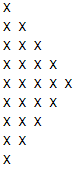

Avoid using trivial solutions like:

print('X') 

print('X X')

print('X X X')

.....

print('X X X')

print('X X')

print('X')


In [1]:
# Exercise 1.1
sizes = [1, 2, 3, 4, 5, 4, 3, 2, 1]
for k in sizes:
    print(("X " * k).strip())

X
X X
X X X
X X X X
X X X X X
X X X X
X X X
X X
X


## Exercise 1.2

Write a script that will sum all numbers in the following string. You can split each number into single digits, so for example, you can consider 45 to be 4 and 5

In [3]:
# Exercise 1.2
input_str = "n45as29@#8ss6"

total = 0
for ch in input_str:
    if ch.isdigit():
        total += int(ch)

print(total)


34


## Exercise 1.3

Write a script that will convert an arbitrary integer to a binary number (the number will be represented as a string with only *0* and *1*). Avoid using the *bin()* function or any other pythons default functions

In [4]:
# Exercise 1.3
n = 42

sign = ""
if n < 0:
    sign = "-"
    n = -n

if n == 0:
    b = "0"
else:
    bits = []
    while n > 0:
        bits.append(str(n % 2))
        n //= 2
    b = "".join(bits[::-1])

print(sign + b)

101010


## Exercise 1.4 - The Fibonacci Sequence:

The Fibonacci Sequence is a series of numbers. The following number is found by adding up the two numbers before it. The first two numbers are 0 and 1. For example, 0, 1, 1, 2, 3, 5, 8, 13. The following number in this series above is 8 + 13 = 21


Your task is to implement a function *fibonacci* that takes an integer as an input and returns a list that contains all Fibonacci numbers with values lower than the input integer

Example:

*print(fibonaci(10))*

[0, 1, 1, 2, 3, 5, 8]


In [5]:
# Exercise 1.4
def fibonacci(upper_threshold: int) -> list:
    if upper_threshold <= 0:
        return []

    seq = [0]
    if upper_threshold == 1:
        return seq

    a, b = 0, 1
    while b < upper_threshold:
        seq.append(b)
        a, b = b, a + b

    return seq

print(fibonacci(10))


[0, 1, 1, 2, 3, 5, 8]


#### Advanced

Try to implement the function using multiple approaches: *Iterative approach*, *Recusrion*, *Memoization*

## Exercise 1.5. -  Rock, Paper, Scissors game:

#### basic

*Rock, Paper, Scissors* is a well-known and straightforward game. If you do not know the rules, google them. We will write a code for the Rock, Paper, Scissors game where the user plays against a random computer. The code can be written into one function *rock_paper_scissors*.

Notes:
- This implementation uses the **random** library to enable the computer to make a random choice.
- Keyword **Input** may be helpful. Check it
- After the function is run, the program will ask you about your movement, which you type in
- The game is case-insensitive for user input (e.g., "rock", "Rock", and "ROCK" are all valid).
- This script plays one round of the game.
- The script prints the result ('You lose', 'You win', 'It is a tie')


In [17]:
# Exercise 1.5
import random

def rock_paper_scissors() -> None:
    choices = ["rock", "paper", "scissors"]
    user = input("Choose rock, paper, or scissors: ").strip().lower()

    while user not in choices:
        user = input("Please type rock, paper, or scissors: ").strip().lower()

    cpu = random.choice(choices)
    print("Computer chose:", cpu)

    if user == cpu:
        print("Draw")
    elif (user == "rock" and cpu == "scissors") or (user == "paper" and cpu == "rock") or (user == "scissors" and cpu == "paper"):
        print("You win")
    else:
        print("You lose")

rock_paper_scissors()


Choose rock, paper, or scissors:  rock


Computer chose: scissors
You win


#### Advanced

Extend the Rock, Paper, Scissors game to be able to play *n* rounds. 

Notes: 
- The scrips will contain two counters - user score and computer score
- After each run, the script prints the current scores and rounds.
- When the number of rounds is reached, the script prints the result ('You lose', 'You win', 'It is a tie')

# Exercise 2

The purpose of this excercise is to practise working with NumPy library

## Exercise 2.1


In this exercise, you will work with NumPy arrays and learn how to efficiently modify and process them using both loops and vectorized operations. Your task is to:

1. Implement the function *create_array_nxn* that generates an n×n NumPy array filled with numbers from n² - 1 down to 0
2. Using a loop-based approach (for-loop, while-loop), implement the function *apply_threshold_loop* that takes any NumPy array and replaces all numbers below a user-defined threshold with 0.
3. Implement function *apply_threshold_vectorized* that performs the same operation as *apply_threshold_loop*, but without loops, using NumPy vectorized operations
4. Implement function *compare_performance* that compares the execution time of functions *apply_threshold_vectorized* and *apply_threshold_loop* with **time** library and print the results


**Additional Notes**:

- Ensure n is a positive integer (n > 0).
- Use the time library to measure execution times for performance comparison.
- The function *compare_performance(n, threshold)* should:
    - Generate an n×n array.
    - Apply both loop-based and vectorized thresholding.
    - Print execution times.

In [18]:
import numpy as np
import time

In [19]:
# Exercise 2.1
def create_array_nxn(n: int) -> np.ndarray:
    if not isinstance(n, int) or n <= 0:
        raise ValueError("n must be a positive integer")
    arr = np.arange(n*n - 1, -1, -1)
    return arr.reshape(n, n)


In [20]:
def apply_threshold_loop(arr: np.ndarray, threshold: int) -> np.ndarray:
    out = np.array(arr, copy=True)
    for i in range(out.shape[0]):
        for j in range(out.shape[1]):
            if out[i, j] < threshold:
                out[i, j] = 0
    return out


In [21]:
def apply_threshold_vectorized(arr: np.ndarray, threshold: int) -> np.ndarray:
    out = np.array(arr, copy=True)
    out[out < threshold] = 0
    return out


In [25]:
def compare_performance(n: int, threshold: int) -> None:
    x = create_array_nxn(n)

    t0 = time.time()
    a = apply_threshold_loop(x, threshold)
    t1 = time.time()

    t2 = time.time()
    b = apply_threshold_vectorized(x, threshold)
    t3 = time.time()

    print("Loop time      :", t1 - t0)
    print("Vectorized time:", t3 - t2)
    print("Same result    :", np.array_equal(a, b))

compare_performance(500, 100000)


Loop time      : 0.06107306480407715
Vectorized time: 0.004915475845336914
Same result    : True


## Exercise 2.2 - Digi display

#### basic

The task will be to create a simulation of a Digi display that will be able to display an arbitrary integer
   
*hint: to show the image, use the library matplotlib.pyplot. Also, you may find function *np.concatenate* helpful

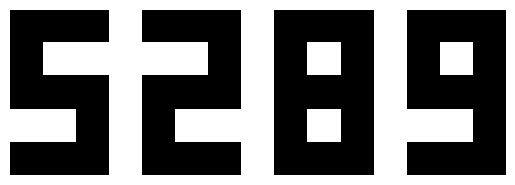

In [30]:
# Exercise 2.2
def show_in_digi(input_integer: int) -> None:
    local = dict(numbs)
    local["-"] = np.array([[0, 0, 0],
                           [0, 0, 0],
                           [1, 1, 1],
                           [0, 0, 0],
                           [0, 0, 0]])
    local["."] = np.array([[0],
                           [0],
                           [0],
                           [0],
                           [1]])

    s = str(input_integer)
    parts = []
    space = np.zeros((5, 1), dtype=int)

    for ch in s:
        if ch not in local:
            continue
        parts.append(local[ch])
        parts.append(space)

    if len(parts) == 0:
        display = np.zeros((5, 3), dtype=int)
    else:
        display = np.concatenate(parts[:-1], axis=1)

    plt.figure()
    plt.imshow(display, cmap="gray_r")
    plt.axis("off")
    plt.show()
show_in_digi(5289)


In [27]:
import matplotlib.pyplot as plt

show_in_digi(5289) will show:


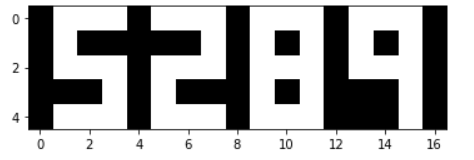

*hint2: you may find the following dict usefull*

In [29]:
numbs = {
      "1": np.array([[0, 1, 1], [1, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1]]), # 1
      "2": np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [1, 0, 0], [1, 1, 1]]), # 2
      "3": np.array([[1, 1, 1], [0, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 3
      "4": np.array([[1, 0, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [0, 0, 1]]), # 4
      "5": np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 5
      "6": np.array([[1, 1, 1], [1, 0, 0], [1, 1, 1], [1, 0, 1], [1, 1, 1]]), # 6
      "7": np.array([[1, 1, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1], [0, 0, 1]]), # 7
      "8": np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [1, 0, 1], [1, 1, 1]]), # 8
      "9": np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1], [0, 0, 1], [1, 1, 1]]), # 9
      "0": np.array([[1, 1, 1], [1, 0, 1], [1, 0, 1], [1, 0, 1], [1, 1, 1]]), # 0
  }

#### advanced

Extend your *show_in_digi* function to be able to display an arbitary float number and negative numbers

# Exercise 3 - Playing with California Housing Dataset

The purpose of this exercise is to learn basic operations of **pandas** library. Use *california_housing_dataset* you can find in google colab to do following operations:

In [36]:
from sklearn.datasets import fetch_california_housing

cal = fetch_california_housing(as_frame=True)
df = cal.frame  # contains features + target

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


- check what *dataset.describe()* does

In [37]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


- display all rows where *total_bedrooms* column is bigger than 310

In [38]:
df[df["AveBedrms"] > 3.10]

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
1024,3.1500,16.0,29.852941,5.323529,202.0,1.980392,38.52,-120.00,1.406
1102,2.4028,17.0,31.777778,9.703704,47.0,1.740741,40.06,-121.54,0.675
1233,3.7500,10.0,16.847534,3.237668,546.0,2.448430,38.23,-120.34,1.214
1234,4.4063,13.0,28.757282,5.300971,252.0,2.446602,38.26,-120.33,1.558
1238,3.3542,10.0,28.112903,5.604839,298.0,2.403226,38.29,-120.27,1.038
...,...,...,...,...,...,...,...,...,...
19976,3.1250,10.0,21.095238,5.285714,48.0,2.285714,36.19,-118.37,0.713
19977,2.3937,20.0,18.793522,5.263158,658.0,2.663968,35.82,-118.70,0.821
20093,2.0625,37.0,24.669118,4.897059,338.0,2.485294,38.12,-120.12,0.889
20094,2.1250,26.0,37.063492,7.185185,416.0,2.201058,38.19,-120.03,1.325


- drop also first and last row

In [39]:
df = df.drop([df.index[0], df.index[-1]])
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697


- save a mean of values in *households* columns to variable, using *matplotlib* display number of households in the graph (x-axis would be ID, y-axis - numbers of households) as dots with the same color, display also mean as a single line in the graph with different color as dots is

Mean population: 1425.5320767516232


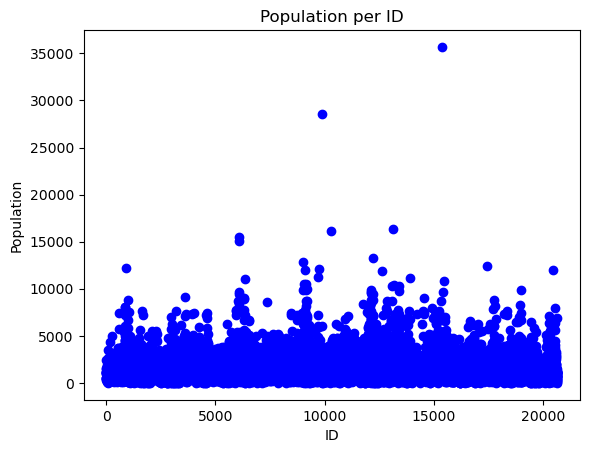

In [40]:
mean_population = df["Population"].mean()
print("Mean population:", mean_population)

plt.figure()
plt.plot(df.index, df["Population"], "bo")
plt.xlabel("ID")
plt.ylabel("Population")
plt.title("Population per ID")
plt.show()

 - check if any of the columns contain NaN values, if yes, replace the NaN values with the arithmetic mean of the whole dataset 

In [41]:
print(df.isna().sum())

df = df.fillna(df.mean())

print("After replacement:")
print(df.isna().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64
After replacement:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


 - display *lat* and *long* into plot, *lat* would be on *x* axis and *long* on *y* axis 

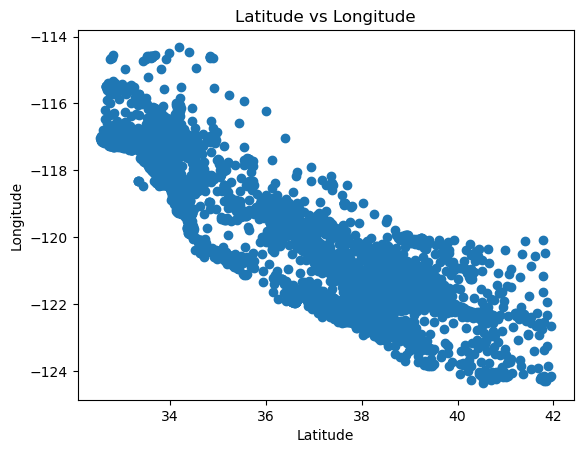

In [42]:
plt.figure()
plt.scatter(df["Latitude"], df["Longitude"])
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("Latitude vs Longitude")
plt.show()

- choose two arbitrary columns and normalize all values inside using *min-max normalization*:

In [43]:
cols = ["MedInc", "AveRooms"]

for col in cols:
    min_val = df[col].min()
    max_val = df[col].max()
    df[col] = (df[col] - min_val) / (max_val - min_val)

df[cols].head()

,MedInc,AveRooms
1,0.538027,0.038224
2,0.466028,0.052756
3,0.354699,0.035241
4,0.230776,0.038534
5,0.243921,0.027757


- Create a Correlation Matrix from all columns 

               MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc       1.000000 -0.119207  0.326873  -0.062027    0.004945  0.018773   
HouseAge    -0.119207  1.000000 -0.153320  -0.077737   -0.296221  0.013192   
AveRooms     0.326873 -0.153320  1.000000   0.847636   -0.072186 -0.004851   
AveBedrms   -0.062027 -0.077737  0.847636   1.000000   -0.066206 -0.006181   
Population   0.004945 -0.296221 -0.072186  -0.066206    1.000000  0.069862   
AveOccup     0.018773  0.013192 -0.004851  -0.006181    0.069862  1.000000   
Latitude    -0.079882  0.011209  0.106375   0.069724   -0.108746  0.002373   
Longitude   -0.015060 -0.108186 -0.027504   0.013341    0.099717  0.002471   
MedHouseVal  0.687989  0.105492  0.151902  -0.046684   -0.024555 -0.023738   

             Latitude  Longitude  MedHouseVal  
MedInc      -0.079882  -0.015060     0.687989  
HouseAge     0.011209  -0.108186     0.105492  
AveRooms     0.106375  -0.027504     0.151902  
AveBedrms    0.069724   0.0

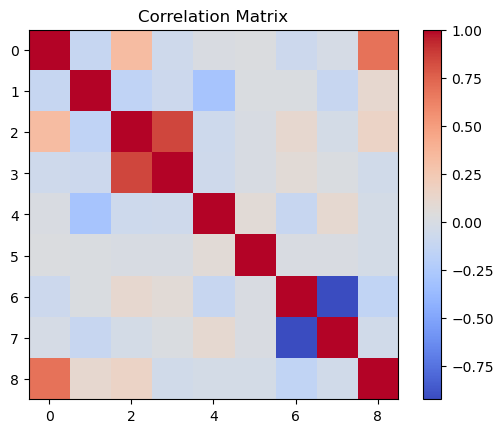

In [44]:
corr = df.corr()
print(corr)

plt.figure()
plt.imshow(corr, cmap="coolwarm")
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()